#Import modules

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Load & prepare data

##Metabolomics

In [ ]:
metabolomics = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_data_processed/metabolites_fudan_hmdb.csv', index_col = 0)
metabolomics

,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,HMDB0000696,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC002,21.291669,17.379201,19.533546,14.752381,17.281514,13.438272,15.498725,15.460840,17.108708,18.389594,...,15.014544,16.147682,14.095067,19.686661,11.607330,15.498725,15.209910,17.454026,14.036174,12.963980
FUSCCTNBC049,22.449926,16.339084,19.881713,14.788514,19.866545,13.159556,15.739253,15.798674,14.671762,18.054933,...,14.693705,13.076816,13.666224,20.624987,13.371777,16.040461,14.952195,14.508042,13.938477,12.983706
FUSCCTNBC053,23.202486,17.216357,19.696190,14.371777,17.997979,14.010178,14.970286,16.732366,14.027560,18.714715,...,14.747144,12.264443,14.609640,21.766542,11.264443,16.055367,14.778283,11.903129,14.103288,12.593391
FUSCCTNBC060,22.470636,16.215609,20.109475,16.133704,18.747767,13.872675,16.031873,15.855744,15.247483,18.138002,...,13.699139,14.720672,13.666224,20.864579,13.024101,16.395400,13.992584,15.798674,14.258566,12.967587
FUSCCTNBC061,22.773308,17.616161,19.755466,16.446373,20.537163,14.143702,14.344296,15.646671,17.253183,18.775350,...,16.169377,17.936161,16.866820,21.061099,13.168985,17.718038,14.036174,12.576957,10.987264,13.091766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC100_N,21.764207,16.881198,20.037044,16.145693,2.378512,13.138912,15.457637,14.773139,14.988152,18.232852,...,13.938477,16.962738,12.246741,20.862873,14.919981,16.473579,14.309192,14.838613,13.451211,13.586371
FUSCCTNBC057_N,20.592852,16.970218,20.405553,16.080568,18.882330,13.501837,15.723341,15.660664,9.324181,17.181570,...,2.691534,16.589300,10.569856,20.332841,13.803728,16.982459,11.316282,14.660664,13.344296,12.987264
FUSCCTNBC252_N,18.964724,17.817633,20.577451,15.589300,2.715893,12.859146,14.580494,13.853310,14.747144,14.470405,...,12.912515,12.956739,12.240791,20.039388,12.943980,17.606644,13.992584,12.369052,2.715893,2.715893
FUSCCTNBC068_N,21.215000,16.183015,20.249903,15.912983,18.598798,13.699139,15.693705,15.111462,12.225810,17.796990,...,2.469886,13.249706,12.655083,20.496816,13.148477,16.512679,14.905951,14.258566,13.688250,12.819780


##Split data to PIK3CA WT vs MUT

In [ ]:
cnv = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/Fudan_TripleNegative/FUSCC_TNBC_annotation_withCNV.txt', sep = '\t')
cnv

,Transcriptomic_Sample,Tumour,HR_status,HER2_status,TNBC_status,PI3K_mutation_status,PTEN_status,PI3K_activity_status,MYC_status
0,FUSCCTNBC001,Tumor,HR-,HER2-,TNBC+,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_Gain
1,FUSCCTNBC003,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
2,FUSCCTNBC004,Tumor,HR-,HER2-,TNBC+,NaN,PTEN_Deletion,PI3K_PTEN_mut,MYC_Amplification
3,FUSCCTNBC005,Tumor,HR-,HER2-,TNBC+,PI3K_mut,PTEN_Deletion,PI3K_PTEN_mut,MYC_Amplification
4,FUSCCTNBC006,Tumor,HR-,HER2-,TNBC+,PI3K_WT,PTEN_Gain,PI3K_PTEN_WT,MYC_Gain
...,...,...,...,...,...,...,...,...,...
313,FUSCCTNBC491,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
314,FUSCCTNBC492,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
315,FUSCCTNBC493,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
316,FUSCCTNBC494,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN


In [ ]:
pi3k = cnv[['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k

,Transcriptomic_Sample,PI3K_activity_status
0,FUSCCTNBC001,PI3K_PTEN_mut
1,FUSCCTNBC003,NaN
2,FUSCCTNBC004,PI3K_PTEN_mut
3,FUSCCTNBC005,PI3K_PTEN_mut
4,FUSCCTNBC006,PI3K_PTEN_WT
...,...,...
313,FUSCCTNBC491,NaN
314,FUSCCTNBC492,NaN
315,FUSCCTNBC493,NaN
316,FUSCCTNBC494,NaN


In [ ]:
pi3k.PI3K_activity_status.value_counts()

,count
PI3K_activity_status,
PI3K_PTEN_mut,181
PI3K_PTEN_WT,92


In [ ]:
pi3k = pi3k[['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k = pi3k.dropna()
pi3k = pi3k.set_index('Transcriptomic_Sample')
pi3k

,PI3K_activity_status
Transcriptomic_Sample,
FUSCCTNBC001,PI3K_PTEN_mut
FUSCCTNBC004,PI3K_PTEN_mut
FUSCCTNBC005,PI3K_PTEN_mut
FUSCCTNBC006,PI3K_PTEN_WT
FUSCCTNBC007,PI3K_PTEN_mut
...,...
FUSCCTNBC465,PI3K_PTEN_mut
FUSCCTNBC467,PI3K_PTEN_WT
FUSCCTNBC468,PI3K_PTEN_mut


In [ ]:
pi3k = pi3k.loc[pi3k.index.intersection(metabolomics.index)]
pi3k

,PI3K_activity_status
FUSCCTNBC001,PI3K_PTEN_mut
FUSCCTNBC004,PI3K_PTEN_mut
FUSCCTNBC005,PI3K_PTEN_mut
FUSCCTNBC006,PI3K_PTEN_WT
FUSCCTNBC007,PI3K_PTEN_mut
...,...
FUSCCTNBC441,PI3K_PTEN_WT
FUSCCTNBC443,PI3K_PTEN_WT
FUSCCTNBC451,PI3K_PTEN_WT
FUSCCTNBC456,PI3K_PTEN_mut


In [ ]:
pi3k.isna().sum()

,0
PI3K_activity_status,0


In [ ]:
pi3k_status = []
for i in pi3k.PI3K_activity_status:
  if i  == 'PI3K_PTEN_WT':
    pi3k_status.append('WT')
  else:
    pi3k_status.append('MUT')

In [ ]:
pi3k['PI3K'] = pi3k_status
pi3k = pi3k.drop('PI3K_activity_status', axis = 'columns')
pi3k

,PI3K
FUSCCTNBC001,MUT
FUSCCTNBC004,MUT
FUSCCTNBC005,MUT
FUSCCTNBC006,WT
FUSCCTNBC007,MUT
...,...
FUSCCTNBC441,WT
FUSCCTNBC443,WT
FUSCCTNBC451,WT
FUSCCTNBC456,MUT


In [ ]:
pi3k.PI3K.value_counts()

,count
PI3K,
MUT,131
WT,71


In [ ]:
def select_and_add_pi3k_status(df, pi3k_df):
  common_index = list(df.index.intersection(pi3k_df.index))
  res = pd.concat([pi3k_df.loc[common_index], df.loc[common_index]], axis = 'columns')
  return res

In [ ]:
metabolomics_pi3k = select_and_add_pi3k_status(df = metabolomics, pi3k_df = pi3k)
metabolomics_pi3k

,PI3K,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC034,MUT,19.946314,17.235322,20.114399,14.476746,16.179132,12.576957,15.723341,15.005800,17.177439,...,15.690980,13.677279,14.720672,21.237481,10.987264,17.051804,16.901162,16.410385,13.688250,13.189207
FUSCCTNBC057,WT,23.314930,16.275033,19.219896,13.274669,21.726481,13.741888,15.808763,16.490914,16.084725,...,16.335600,14.532599,16.305634,21.514610,12.237807,17.220444,15.649481,15.626850,14.808763,13.173677
FUSCCTNBC066,MUT,21.764654,16.501837,19.967575,14.078484,15.778283,14.489346,16.305634,16.086800,16.920492,...,14.858175,12.189207,14.905951,20.978901,11.536247,16.709743,15.770561,13.268834,11.648358,12.851359
FUSCCTNBC087,MUT,21.512941,15.677279,19.601481,14.626850,17.192302,14.135709,15.385323,15.775713,15.421933,...,15.082648,14.086800,14.027560,21.072095,11.880349,16.253035,14.568669,13.438272,14.495605,10.670656
FUSCCTNBC100,WT,21.666892,17.409358,19.662686,15.838613,18.731508,14.688250,15.652285,16.352940,13.699139,...,14.757598,16.076398,13.598052,21.424214,13.032735,15.788514,18.277696,11.735556,12.440869,12.718533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC426,MUT,21.471097,17.100662,19.917376,13.699139,20.035280,14.709945,14.053247,15.454428,15.323336,...,15.010178,14.236313,14.677279,21.281952,11.906891,16.034025,14.470405,13.330357,13.965784,12.579316
FUSCCTNBC437,MUT,20.943494,17.718994,20.156153,14.974773,16.441518,14.330357,15.808763,15.580494,18.135183,...,16.497166,15.559736,16.001408,21.039372,11.501837,17.371096,15.938477,11.321928,11.293472,13.574594
FUSCCTNBC438,MUT,20.729863,15.943064,19.997393,15.294908,19.204617,14.001408,14.053247,15.337343,16.769089,...,15.470405,14.151651,14.070121,20.750377,12.805744,17.803690,16.690803,12.971184,13.514221,13.464035
FUSCCTNBC441,WT,20.195412,16.741901,20.256159,16.141708,16.748717,14.151651,15.652285,14.688250,16.368370,...,13.677279,14.457637,13.227315,20.964660,12.655083,14.828732,13.464035,14.294908,12.965784,13.025832


#Pathway Analysis on Metabolomics

##ssPA

In [ ]:
!pip install gseapy
import gseapy as gp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.6/664.6 kB 20.0 MB/s eta 0:00:00


In [ ]:
met_db = pd.read_csv('drive/My Drive/Colab Notebooks/pathbank_pathway_hmdb.csv')
met_db = met_db.dropna()
met_db

,Pathway Name,HMDB ID
0,Alanine Metabolism,HMDB0000538
1,Alanine Metabolism,HMDB0000161
2,Alanine Metabolism,HMDB0000045
3,Alanine Metabolism,HMDB0000250
4,Alanine Metabolism,HMDB0001303
...,...,...
1977776,Methylglyoxal Degradation I,HMDB0000190
1977777,Methylglyoxal Degradation I,HMDB0015532
1977778,Methylglyoxal Degradation I,HMDB0036062
1977779,Methylglyoxal Degradation I,HMDB0000243


In [ ]:
len(met_db['Pathway Name'].unique())

68355

In [ ]:
met_db_dict = met_db.groupby('Pathway Name')['HMDB ID'].apply(list).to_dict()
len(met_db_dict)

68355

In [ ]:
metabolomics_pi3k.drop(labels = ['PI3K'], axis = 'columns').T

,FUSCCTNBC034,FUSCCTNBC057,FUSCCTNBC066,FUSCCTNBC087,FUSCCTNBC100,FUSCCTNBC118,FUSCCTNBC161,FUSCCTNBC178,FUSCCTNBC180,FUSCCTNBC181,...,FUSCCTNBC406,FUSCCTNBC414,FUSCCTNBC418,FUSCCTNBC420,FUSCCTNBC422,FUSCCTNBC426,FUSCCTNBC437,FUSCCTNBC438,FUSCCTNBC441,FUSCCTNBC467
HMDB0000050,19.946314,23.314930,21.764654,21.512941,21.666892,22.287621,20.801070,22.305554,20.557360,21.124894,...,19.880899,21.495696,21.466926,21.302286,22.191601,21.471097,20.943494,20.729863,20.195412,22.063523
HMDB0003229,17.235322,16.275033,16.501837,15.677279,17.409358,16.673226,17.277569,16.583435,16.262242,18.978015,...,17.443203,16.776587,17.336568,16.702457,15.728665,17.100662,17.718994,15.943064,16.741901,14.767978
HMDB0000220,20.114399,19.219896,19.967575,19.601481,19.662686,19.488621,19.490367,19.163662,19.295894,19.584394,...,19.843087,19.649553,19.438552,19.693097,19.449596,19.917376,20.156153,19.997393,20.256159,18.782813
HMDB0000214,14.476746,13.274669,14.078484,14.626850,15.838613,15.001408,13.762797,13.833681,14.398744,13.526499,...,15.291315,13.273213,14.574594,14.221285,14.095067,13.699139,14.974773,15.294908,16.141708,12.461479
HMDB0001173,16.179132,21.726481,15.778283,17.192302,18.731508,16.541702,17.038158,18.142351,19.400857,18.814708,...,16.866084,15.773139,20.994145,17.183587,20.088848,20.035280,16.441518,19.204617,16.748717,17.960268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HMDB0000094,17.051804,17.220444,16.709743,16.253035,15.788514,17.901238,17.641339,16.797510,18.980954,15.963528,...,17.372942,16.352940,15.615400,17.211632,16.044736,16.034025,17.371096,17.803690,14.828732,20.254281
HMDB0000194,16.901162,15.649481,15.770561,14.568669,18.277696,14.464035,14.877476,14.823765,16.177186,13.910643,...,14.183015,15.828732,15.765390,17.092871,15.843529,14.470405,15.938477,16.690803,13.464035,15.364955
HMDB0002994,16.410385,15.626850,13.268834,13.438272,11.735556,12.646109,13.489346,12.083479,13.003167,12.466586,...,11.598052,13.076816,14.316282,12.843529,14.364955,13.330357,11.321928,12.971184,14.294908,11.550747
HMDB0000125,13.688250,14.808763,11.648358,14.495605,12.440869,13.947637,11.625709,14.632541,14.736613,14.273213,...,13.901244,14.078484,14.001408,13.677279,14.358102,13.965784,11.293472,13.514221,12.965784,13.358102


In [ ]:
#This function performs ssgsea and returns the results

def perform_sspa(df, gene_set_library):
  result = pd.DataFrame()

  for sample_id in df.columns:
    sample = df[sample_id]
    ssgsea_results = gp.ssgsea(data=sample, gene_sets=gene_set_library, outdir=None, min_size = 5)
    enrichment_scores = ssgsea_results.res2d
    sample_result = pd.DataFrame()
    for i in enrichment_scores['Name'].unique():
      sample_es = enrichment_scores[enrichment_scores['Name'] == i]
      sample_es = sample_es.rename(columns = {'Term' : ''})
      sample_es = sample_es.set_index('')
      sample_es = sample_es.drop(columns = ['Name', 'ES'])
      sample_es = sample_es.rename(columns = {'NES' : i})
      sample_result = pd.concat([sample_result, sample_es], axis = 'columns')
    result = pd.concat([result, sample_result], axis = 'columns')

  return result

sspa_res = perform_sspa(df = metabolomics_pi3k.drop(labels = ['PI3K'], axis = 'columns').T, gene_set_library = met_db_dict)

sspa_res

,FUSCCTNBC034,FUSCCTNBC057,FUSCCTNBC066,FUSCCTNBC087,FUSCCTNBC100,FUSCCTNBC118,FUSCCTNBC161,FUSCCTNBC178,FUSCCTNBC180,FUSCCTNBC181,...,FUSCCTNBC406,FUSCCTNBC414,FUSCCTNBC418,FUSCCTNBC420,FUSCCTNBC422,FUSCCTNBC426,FUSCCTNBC437,FUSCCTNBC438,FUSCCTNBC441,FUSCCTNBC467
,,,,,,,,,,,,,,,,,,,,,
Tryptophan Metabolism II,0.876601,0.795161,0.626575,0.921480,0.875219,0.837723,0.666276,0.886287,0.719399,0.866826,...,0.877520,0.866493,0.842660,0.814059,0.763566,0.932260,0.903670,0.908158,0.805719,0.791493
Ammonia Recycling,0.726287,0.716682,0.481027,0.781482,0.768841,0.625199,0.619889,0.671241,0.664777,0.759155,...,0.723660,0.651172,0.713113,0.663456,0.770106,0.719293,0.716676,0.642443,0.563940,0.742895
"Phosphatidylcholine/Phosphatidylethanolamine Biosynthesis PC(20:4(5Z,8Z,11Z,14Z)/20:4(8Z,11Z,14Z,17Z)) | PE(20:4(5Z,8Z,11Z,14Z)/20:4(8Z,11Z,14Z,17Z))",0.694788,0.695011,0.479948,0.727734,0.632845,0.572037,0.606643,0.546543,0.485428,0.577836,...,0.578815,0.597502,0.678956,0.616717,0.720806,0.697346,0.753136,0.606129,0.670655,0.607003
"Phosphatidylcholine/Phosphatidylethanolamine Biosynthesis PC(20:3(5Z,8Z,11Z)/20:4(5Z,8Z,11Z,14Z)) | PE(20:3(5Z,8Z,11Z)/20:4(5Z,8Z,11Z,14Z))",0.694788,0.695011,0.479948,0.727734,0.632845,0.572037,0.606643,0.546543,0.485428,0.577836,...,0.578815,0.597502,0.678956,0.616717,0.720806,0.697346,0.753136,0.606129,0.670655,0.607003
"Phosphatidylcholine/Phosphatidylethanolamine Biosynthesis PC(20:1(11Z)/20:4(5Z,8Z,11Z,14Z)) | PE(20:1(11Z)/20:4(5Z,8Z,11Z,14Z))",0.694788,0.695011,0.479948,0.727734,0.632845,0.572037,0.606643,0.546543,0.485428,0.577836,...,0.578815,0.597502,0.678956,0.616717,0.720806,0.697346,0.753136,0.606129,0.670655,0.607003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
beta-Ureidopropionase Deficiency,-0.104564,-0.128840,-0.026742,-0.078520,-0.063459,-0.006448,-0.002497,0.024157,0.043327,0.050860,...,-0.086275,0.041581,-0.015047,-0.185941,-0.105567,-0.044615,-0.096330,-0.086602,-0.067510,-0.161382
Dihydropyrimidinase Deficiency,-0.104564,-0.128840,-0.026742,-0.078520,-0.063459,-0.006448,-0.002497,0.024157,0.043327,0.050860,...,-0.086275,0.041581,-0.015047,-0.185941,-0.105567,-0.044615,-0.096330,-0.086602,-0.067510,-0.161382
MNGIE (Mitochondrial Neurogastrointestinal Encephalopathy),-0.104564,-0.128840,-0.026742,-0.078520,-0.063459,-0.006448,-0.002497,0.024157,0.043327,0.050860,...,-0.086275,0.041581,-0.015047,-0.185941,-0.105567,-0.044615,-0.096330,-0.086602,-0.067510,-0.161382


In [ ]:
sspa_res = sspa_res.fillna(0)

In [ ]:
keep_cols = ['Aspartate Metabolism', 'Glutaminolysis and Cancer',
       'Inner Membrane Transport', 'NAD Metabolism', 'beta-Alanine Metabolism',
       'Urea Cycle',  'Warburg Effect',
       'Arginine and Proline Metabolism',
       'Proline Metabolism', 'Arginine Metabolism',
       'Glycine and Serine Metabolism',
       'Purine Metabolism',
       'Methionine Metabolism', 'Tryptophan Metabolism',
       'Pyrimidine Metabolism',
       'Lysolipid Incorporation into ER PC(16:0/16:0)',
       'Nicotinate and Nicotinamide Metabolism']
sspa_res_keep_cols = sspa_res.reindex(keep_cols, axis = 'index')
sspa_res_keep_cols

,FUSCCTNBC034,FUSCCTNBC057,FUSCCTNBC066,FUSCCTNBC087,FUSCCTNBC100,FUSCCTNBC118,FUSCCTNBC161,FUSCCTNBC178,FUSCCTNBC180,FUSCCTNBC181,...,FUSCCTNBC406,FUSCCTNBC414,FUSCCTNBC418,FUSCCTNBC420,FUSCCTNBC422,FUSCCTNBC426,FUSCCTNBC437,FUSCCTNBC438,FUSCCTNBC441,FUSCCTNBC467
,,,,,,,,,,,,,,,,,,,,,
Aspartate Metabolism,0.587670,0.552624,0.430943,0.670922,0.613693,0.544146,0.527973,0.606449,0.525259,0.622694,...,0.575185,0.645923,0.635438,0.560883,0.691302,0.550188,0.641201,0.581003,0.445926,0.508620
Glutaminolysis and Cancer,0.618963,0.646414,0.456843,0.712888,0.658477,0.663252,0.502788,0.693436,0.694048,0.586467,...,0.677594,0.577733,0.569978,0.597625,0.626011,0.636745,0.769827,0.638384,0.521180,0.701287
Inner Membrane Transport,0.387591,0.315084,0.226538,0.281613,0.311703,0.235328,0.262020,0.342942,0.228573,0.330323,...,0.323917,0.330197,0.274777,0.225597,0.207050,0.269647,0.417969,0.282669,0.319113,0.314754
NAD Metabolism,0.494981,0.516429,0.414777,0.568214,0.532443,0.590073,0.472512,0.608704,0.397928,0.532117,...,0.573198,0.591265,0.519380,0.525994,0.515576,0.534396,0.564698,0.525384,0.444505,0.445196
beta-Alanine Metabolism,0.413205,0.465290,0.232032,0.425205,0.592996,0.343188,0.328445,0.406087,0.476019,0.444042,...,0.371286,0.395796,0.517586,0.449433,0.488626,0.377656,0.381678,0.423062,0.313431,0.480651
Urea Cycle,0.559704,0.496157,0.396717,0.738316,0.645872,0.584517,0.447518,0.526289,0.498755,0.582485,...,0.620879,0.536764,0.561156,0.532195,0.608616,0.470663,0.581953,0.593711,0.620720,0.448775
Warburg Effect,0.537421,0.627869,0.380482,0.628038,0.609625,0.643077,0.447415,0.710356,0.695432,0.490561,...,0.643451,0.558019,0.503097,0.582110,0.584331,0.694794,0.716416,0.691953,0.479074,0.661303
Arginine and Proline Metabolism,0.356762,0.406925,0.256478,0.445078,0.489100,0.426131,0.328598,0.439446,0.381990,0.399950,...,0.441748,0.357308,0.354072,0.388760,0.419021,0.375859,0.467861,0.419726,0.448707,0.397651
Proline Metabolism,0.623988,0.539608,0.436943,0.751561,0.721086,0.647319,0.510085,0.599043,0.571853,0.648748,...,0.698984,0.611622,0.626056,0.637405,0.676734,0.591112,0.630013,0.723497,0.688069,0.517429


In [ ]:
sspa_res_keep_cols = pd.concat([metabolomics_pi3k[['PI3K']], sspa_res_keep_cols.T], axis = 'columns')
sspa_res_keep_cols

,PI3K,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
FUSCCTNBC034,MUT,0.587670,0.618963,0.387591,0.494981,0.413205,0.559704,0.537421,0.356762,0.623988,0.539471,0.608297,0.335046,0.448698,0.436246,0.170330,0.179193,0.633914
FUSCCTNBC057,WT,0.552624,0.646414,0.315084,0.516429,0.465290,0.496157,0.627869,0.406925,0.539608,0.506237,0.654574,0.492177,0.714771,0.487294,0.128340,0.157246,0.694011
FUSCCTNBC066,MUT,0.430943,0.456843,0.226538,0.414777,0.232032,0.396717,0.380482,0.256478,0.436943,0.350924,0.505187,0.393060,0.363969,0.359080,0.157919,0.066214,0.526476
FUSCCTNBC087,MUT,0.670922,0.712888,0.281613,0.568214,0.425205,0.738316,0.628038,0.445078,0.751561,0.650226,0.634053,0.608274,0.594747,0.473772,0.260554,0.196365,0.849239
FUSCCTNBC100,WT,0.613693,0.658477,0.311703,0.532443,0.592996,0.645872,0.609625,0.489100,0.721086,0.623166,0.667342,0.483129,0.630437,0.454384,0.209923,0.000439,0.773366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC426,MUT,0.550188,0.636745,0.269647,0.534396,0.377656,0.470663,0.694794,0.375859,0.591112,0.546486,0.671843,0.513736,0.548943,0.402153,0.152377,0.099535,0.824894
FUSCCTNBC437,MUT,0.641201,0.769827,0.417969,0.564698,0.381678,0.581953,0.716416,0.467861,0.630013,0.644942,0.625889,0.443798,0.532559,0.444938,0.199741,0.259322,0.761541
FUSCCTNBC438,MUT,0.581003,0.638384,0.282669,0.525384,0.423062,0.593711,0.691953,0.419726,0.723497,0.609041,0.687002,0.434139,0.503106,0.382718,0.139592,0.145390,0.817505
FUSCCTNBC441,WT,0.445926,0.521180,0.319113,0.444505,0.313431,0.620720,0.479074,0.448707,0.688069,0.626191,0.623424,0.314731,0.398964,0.383266,0.135372,0.279586,0.622055


#Plots

##Plot pyrimidine & purine metabolism

In [ ]:
save_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Cell_Reports_revisions_res'

In [ ]:
import os

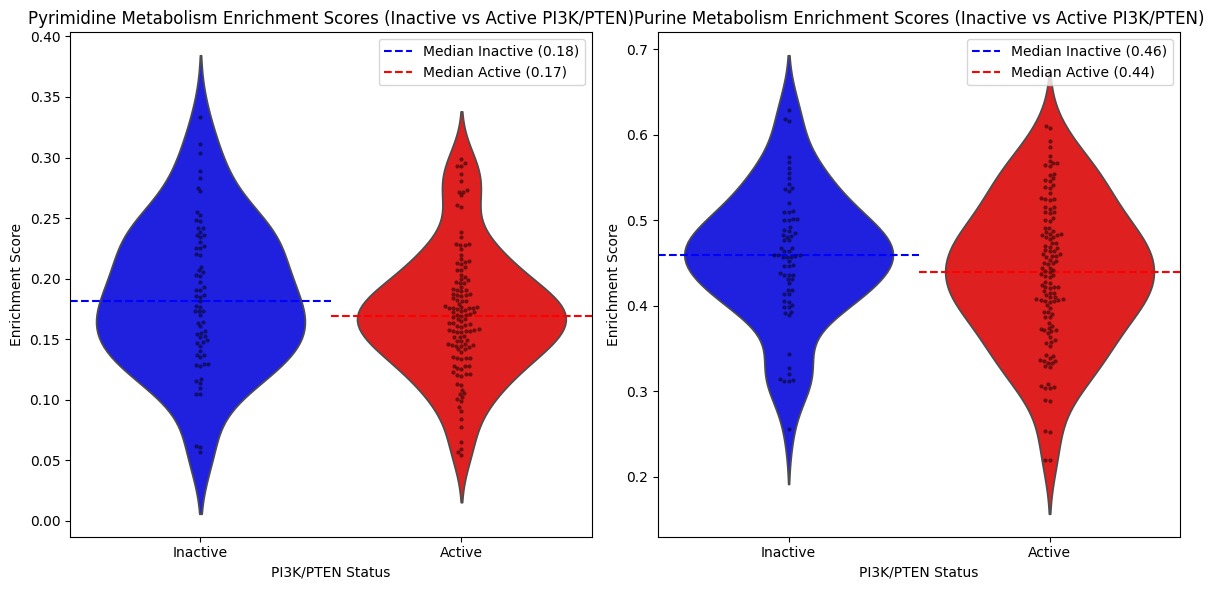

In [ ]:
pathways_to_plot = ['Pyrimidine Metabolism', 'Purine Metabolism']
plot_data = sspa_res_keep_cols[['PI3K'] + pathways_to_plot]
plot_data = plot_data.replace('WT', 'Inactive').replace('MUT', 'Active')

plot_data_melted = plot_data.melt(id_vars='PI3K', var_name='Pathway', value_name='Enrichment Score')

pi3k_order = ['Inactive', 'Active']

plt.figure(figsize=(12, 6))

# --- Pyrimidine Metabolism Plot ---
plt.subplot(1, 2, 1)
subset_data_pyr = plot_data_melted[plot_data_melted['Pathway'] == 'Pyrimidine Metabolism']
sns.violinplot(x='PI3K', y='Enrichment Score', data=subset_data_pyr, palette={'Active': 'red', 'Inactive': 'blue'}, hue='PI3K', legend=False, order=pi3k_order, inner=None)
sns.swarmplot(x='PI3K', y='Enrichment Score', data=subset_data_pyr, color='black', size=3, alpha=0.5, order=pi3k_order)

median_inactive_pyr = subset_data_pyr[subset_data_pyr['PI3K'] == 'Inactive']['Enrichment Score'].median()
median_active_pyr = subset_data_pyr[subset_data_pyr['PI3K'] == 'Active']['Enrichment Score'].median()

plt.axhline(y=median_inactive_pyr, color='blue', linestyle='--', label=f'Median Inactive ({median_inactive_pyr:.2f})', xmin=0.0, xmax=0.5) # xmin/xmax relative to subplot
plt.axhline(y=median_active_pyr, color='red', linestyle='--', label=f'Median Active ({median_active_pyr:.2f})', xmin=0.5, xmax=1.0)
plt.legend(loc='upper right')
plt.title('Pyrimidine Metabolism Enrichment Scores (Inactive vs Active PI3K/PTEN)')
plt.xlabel('PI3K/PTEN Status')
plt.ylabel('Enrichment Score')

# --- Purine Metabolism Plot ---
plt.subplot(1, 2, 2)
subset_data_pur = plot_data_melted[plot_data_melted['Pathway'] == 'Purine Metabolism']
sns.violinplot(x='PI3K', y='Enrichment Score', data=subset_data_pur, palette={'Active': 'red', 'Inactive': 'blue'}, hue='PI3K', legend=False, order=pi3k_order, inner=None)
sns.swarmplot(x='PI3K', y='Enrichment Score', data=subset_data_pur, color='black', size=3, alpha=0.5, order=pi3k_order)

median_inactive_pur = subset_data_pur[subset_data_pur['PI3K'] == 'Inactive']['Enrichment Score'].median()
median_active_pur = subset_data_pur[subset_data_pur['PI3K'] == 'Active']['Enrichment Score'].median()

plt.axhline(y=median_inactive_pur, color='blue', linestyle='--', label=f'Median Inactive ({median_inactive_pur:.2f})', xmin=0.0, xmax=0.5)
plt.axhline(y=median_active_pur, color='red', linestyle='--', label=f'Median Active ({median_active_pur:.2f})', xmin=0.5, xmax=1.0)
plt.legend(loc='upper right')
plt.title('Purine Metabolism Enrichment Scores (Inactive vs Active PI3K/PTEN)')
plt.xlabel('PI3K/PTEN Status')
plt.ylabel('Enrichment Score')

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'Fudan_Pyrimidine_Purine_Metabolism_Enrichment_Scores.svg'), bbox_inches='tight')
plt.show()

##t-tests

In [ ]:
from scipy import stats

pathways = ['Pyrimidine Metabolism', 'Purine Metabolism']

for pathway in pathways:
    mut_scores = sspa_res_keep_cols[sspa_res_keep_cols['PI3K'] == 'MUT'][pathway].dropna()
    wt_scores = sspa_res_keep_cols[sspa_res_keep_cols['PI3K'] == 'WT'][pathway].dropna()

    # Perform Welch's t-test (assuming unequal variances)
    t_stat, p_value = stats.ttest_ind(wt_scores, mut_scores, equal_var=False)

    print(f"T-test for {pathway}:")
    print(f"  - T-statistic: {t_stat:.4f}")
    print(f"  - P-value: {p_value:.4f}")
    print("\n")

T-test for Pyrimidine Metabolism:
  - T-statistic: 1.7296
  - P-value: 0.0861


T-test for Purine Metabolism:
  - T-statistic: 1.8088
  - P-value: 0.0724


